In [ ]:
# ============================================================
# 0. SETUP & LOAD DATA
# ============================================================
import pandas as pd
import numpy as np
import os

os.makedirs("output", exist_ok=True)

FILE_PATH = "Vahan_Case_Study.xlsx"

df = pd.read_excel(FILE_PATH, sheet_name="Raw Data")
df.columns = [c.strip() for c in df.columns]

print("ACTUAL COLUMNS IN YOUR FILE:")
print(df.columns.tolist())
print("\nShape:", df.shape)
df.head()

ACTUAL COLUMNS IN YOUR FILE:
['upload_date', 'lead_source', 'candidate_phone', 'Uploaded Leads', 'Attempted', 'Connected', 'Attempt per Lead', 'tag_filled', 'Interested', 'OB_after_upload', 'OB_after_first_attempt', 'FT_after_upload', 'FT_after_first_attempt', 'upload_to_first_attempt_P50 (hrs)', 'Attempted %', 'Attempt → Connected %', 'Connect → Interested %', 'Interested → FT_after_first_attempt %', 'Attempted → FT_after_upload %']

Shape: (18198, 19)


,upload_date,lead_source,candidate_phone,Uploaded Leads,Attempted,Connected,Attempt per Lead,tag_filled,Interested,OB_after_upload,OB_after_first_attempt,FT_after_upload,FT_after_first_attempt,upload_to_first_attempt_P50 (hrs),Attempted %,Attempt → Connected %,Connect → Interested %,Interested → FT_after_first_attempt %,Attempted → FT_after_upload %
0,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,91148e89d497914604c9c248ccd2aca212fac665bdc396...,1,1,1,1.0,1,0,0,0,0,0,112.0,100,100.0,0.0,NaN,0.0
1,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,4aa4e7a4f4a3b9fa608c4c1729be6a8accc31f58b3d8b1...,1,1,0,1.0,0,0,0,0,0,0,112.0,100,0.0,NaN,NaN,0.0
2,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,0e97e34090259c1ce6cef1fd1c491fcfc469ba9d2d1ce7...,1,1,0,1.0,0,0,0,0,0,0,89.0,100,0.0,NaN,NaN,0.0
3,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,cdc003718802cffa769a478bcc0fe31aa20ac3ffe97a7c...,1,1,0,1.0,0,0,0,0,0,0,106.0,100,0.0,NaN,NaN,0.0
4,2026-07-18,2W3W - 3WAHD - Khanna - 3W - 17 Jul,d70833a770ab63e1992254dad148b100bbbadbe0e94673...,1,1,0,1.0,0,0,0,0,0,0,90.0,100,0.0,NaN,NaN,0.0


In [ ]:
# ============================================================
# 0b. AUTO-DETECT COLUMN NAMES (handles underscore/spacing differences)
# ============================================================
def find_col(possible_names):
    for name in possible_names:
        for col in df.columns:
            if col.strip().lower() == name.strip().lower():
                return col
    raise KeyError(f"None of {possible_names} found in columns: {df.columns.tolist()}")

col_upload_date   = find_col(["upload_date", "uploaddate"])
col_leadsource    = find_col(["lead_source", "leadsource"])
col_phone         = find_col(["candidate_phone", "candidatephone"])
col_uploaded      = find_col(["Uploaded Leads", "uploaded_leads"])
col_attempted     = find_col(["Attempted"])
col_connected     = find_col(["Connected"])
col_attempt_lead  = find_col(["Attempt per Lead", "attempt_per_lead"])
col_tagfilled     = find_col(["tag_filled", "tagfilled"])
col_interested    = find_col(["Interested"])
col_ob_upload     = find_col(["OB_after_upload", "OBafterupload"])
col_ob_first      = find_col(["OB_after_first_attempt", "OBafterfirstattempt"])
col_ft_upload     = find_col(["FT_after_upload", "FTafterupload"])
col_ft_first      = find_col(["FT_after_first_attempt", "FTafterfirstattempt"])
col_p50hrs        = find_col([
    "upload_to_first_attempt_P50 (hrs)",
    "upload_to_first_attempt_P50_hrs",
    "uploadtofirstattemptP50 hrs",
    "uploadtofirstattemptP50hrs"
])

print("Mapped columns successfully:")
for name, col in [("upload_date",col_upload_date),("leadsource",col_leadsource),
                   ("uploaded",col_uploaded),("attempted",col_attempted),
                   ("connected",col_connected),("attempt_per_lead",col_attempt_lead),
                   ("tagfilled",col_tagfilled),("interested",col_interested),
                   ("ob_upload",col_ob_upload),("ob_first",col_ob_first),
                   ("ft_upload",col_ft_upload),("ft_first",col_ft_first),
                   ("p50hrs",col_p50hrs)]:
    print(f"  {name:18s} -> '{col}'")

Mapped columns successfully:
  upload_date        -> 'upload_date'
  leadsource         -> 'lead_source'
  uploaded           -> 'Uploaded Leads'
  attempted          -> 'Attempted'
  connected          -> 'Connected'
  attempt_per_lead   -> 'Attempt per Lead'
  tagfilled          -> 'tag_filled'
  interested         -> 'Interested'
  ob_upload          -> 'OB_after_upload'
  ob_first           -> 'OB_after_first_attempt'
  ft_upload          -> 'FT_after_upload'
  ft_first           -> 'FT_after_first_attempt'
  p50hrs             -> 'upload_to_first_attempt_P50 (hrs)'


In [ ]:
# ============================================================
# 1. TOP 3 COHORTS
# ============================================================
MIN_VOLUME = 30

cohort_summary = df.groupby(col_leadsource).agg(
    total_leads=(col_uploaded, "sum"),
    attempted=(col_attempted, "sum"),
    connected=(col_connected, "sum"),
    interested=(col_interested, "sum"),
    onboarded=(col_ob_upload, "sum"),
    ft_count=(col_ft_upload, "sum"),
    ft_count_first_attempt=(col_ft_first, "sum"),
    median_hrs_to_first_attempt=(col_p50hrs, "median"),
).reset_index()

cohort_summary["ft_rate_pct"] = (cohort_summary["ft_count"] / cohort_summary["total_leads"] * 100).round(2)
cohort_summary["connect_rate_pct"] = (cohort_summary["connected"] / cohort_summary["attempted"] * 100).round(2)
cohort_summary["interest_rate_pct"] = (cohort_summary["interested"] / cohort_summary["connected"] * 100).round(2)
cohort_summary["attempt_to_ft_pct"] = (cohort_summary["ft_count"] / cohort_summary["attempted"] * 100).round(2)

print(cohort_summary.sort_values("ft_rate_pct", ascending=False).head(10))

qualified = cohort_summary[cohort_summary["total_leads"] >= MIN_VOLUME].copy()
top3 = qualified.sort_values("ft_rate_pct", ascending=False).head(3)

print(f"\n=== TOP 3 COHORTS (min volume = {MIN_VOLUME} leads, ranked by FT rate) ===")
print(top3[[col_leadsource, "total_leads", "ft_count", "ft_rate_pct",
            "connect_rate_pct", "interest_rate_pct"]])

cohort_summary.to_csv("output/cohort_summary_full.csv", index=False)
top3.to_csv("output/top3_cohorts.csv", index=False)

                                    lead_source  total_leads  attempted  \
15           Single Referral > 7 days- 24th Jul         1500       1454   
11                          Khanna- 2W 26th Jul         1546       1376   
13          PreOb-Ob Fees Paid 29th Jul (set 1)         1483       1433   
14          PreOb-Ob Fees Paid 29th Jul (set 2)         1558       1519   
6   AI Connected but not Connected by TC- Set 1         1480       1331   
7   AI Connected but not Connected by TC- Set 2         1193       1066   
10                                    Khanna AI          886        245   
12                   OLX - Ashwin - 2W - 17 Jul         5182        962   
0           2W3W - 3WAHD - Khanna - 3W - 17 Jul          495        495   
1           2W3W - 3WCNG - Khanna - 3W - 17 Jul          530        530   

    connected  interested  onboarded  ft_count  ft_count_first_attempt  \
15        690           7         30        14                       2   
11        574          20 

In [ ]:
# ============================================================
# 1b. DATA QUALITY FLAG - negative time-to-first-attempt
# ============================================================
# Khanna AI shows a NEGATIVE median hours-to-first-attempt, meaning the
# logged attempt timestamp precedes the upload timestamp for most of its
# rows. This points to an upstream timestamp/timezone bug in that source
# feed, not a real operational result -- so timing metrics for this cohort
# should not be trusted as a benchmark (its FT rate is still numerically
# valid and included above).

anomaly = cohort_summary[cohort_summary['median_hrs_to_first_attempt'] < 0]
print("Cohorts with a negative median time-to-first-attempt (data quality issue):")
print(anomaly[[col_leadsource, 'total_leads', 'median_hrs_to_first_attempt']])

neg_rows_check = df[(df[col_leadsource] == anomaly[col_leadsource].iloc[0])]
neg_count = (neg_rows_check[col_p50hrs] < 0).sum()
print(f"\n{neg_count} of {len(neg_rows_check)} rows in this cohort have a negative attempt time.")



SELECT
    lead_source AS leadsource,
    COUNT(*)                                                  AS total_leads,
    SUM(Attempted)                                       AS attempted,
    SUM(Connected)                                        AS connected,
    SUM(Interested)                                        AS interested,
    SUM(OB_after_upload)                                          AS onboarded,
    SUM(FT_after_upload)                                          AS ft_count,
    ROUND(SUM(FT_after_upload) * 100.0 / COUNT(*), 2)             AS ft_rate_pct,
    ROUND(SUM(Connected) * 100.0 / SUM(Attempted), 2) AS connect_rate_pct,
    ROUND(SUM(Interested) * 100.0 / SUM(Connected), 2) AS interest_rate_pct,
    ROUND(AVG(upload_to_first_attempt_P50 (hrs)), 1)                                   AS median_time_to_attempt_hrs
FROM raw_leads
GROUP BY lead_source
ORDER BY ft_rate_pct DESC;

                                    lead_source  total_leads  attempted  \
15           Sing

Class balance:
target_ft
0    0.997033
1    0.002967
Name: proportion, dtype: float64
              precision    recall  f1-score   support

           0       1.00      0.76      0.87      4536
           1       0.01      0.43      0.01        14

    accuracy                           0.76      4550
   macro avg       0.50      0.60      0.44      4550
weighted avg       0.99      0.76      0.86      4550

[[3465 1071]
 [   8    6]]


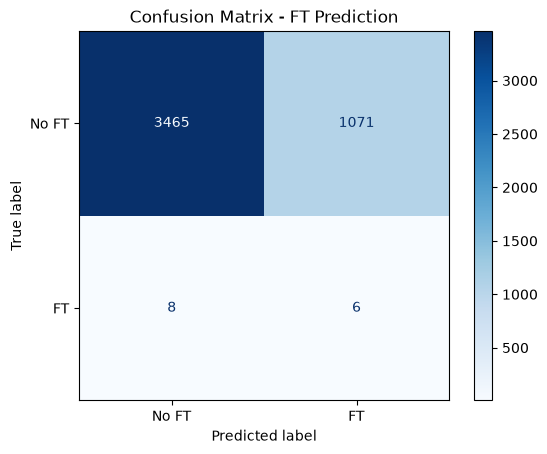

upload_to_first_attempt_P50 (hrs)    0.318888
leadsource_enc                       0.291767
Attempt per Lead                     0.167634
Attempted                            0.141841
tag_filled                           0.038907
Connected                            0.033010
Interested                           0.007951
dtype: float64


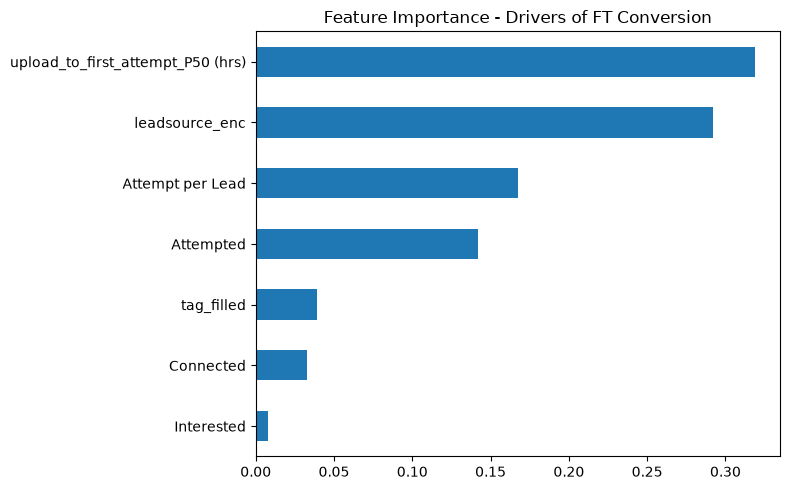

In [ ]:
# ============================================================
# 2. AGGREGATION QUERY (SQL + pandas equivalent)
# ============================================================
SQL_QUERY = f"""
SELECT
    {col_leadsource} AS leadsource,
    COUNT(*)                                                       AS total_leads,
    SUM({col_attempted})                                           AS attempted,
    SUM({col_connected})                                           AS connected,
    SUM({col_interested})                                          AS interested,
    SUM({col_ob_upload})                                           AS onboarded,
    SUM({col_ft_upload})                                           AS ft_count,
    ROUND(SUM({col_ft_upload}) * 100.0 / COUNT(*), 2)              AS ft_rate_pct,
    ROUND(SUM({col_connected}) * 100.0 / SUM({col_attempted}), 2)  AS connect_rate_pct,
    ROUND(SUM({col_interested}) * 100.0 / SUM({col_connected}), 2) AS interest_rate_pct,
    ROUND(AVG(`{col_p50hrs}`), 1)                                  AS median_time_to_attempt_hrs
FROM raw_leads
GROUP BY {col_leadsource}
ORDER BY ft_rate_pct DESC;
"""
# NOTE: upload_to_first_attempt_P50 (hrs) contains a space and parentheses,
# so it must be backtick-quoted (MySQL) or double-quoted (Postgres/ANSI) in
# real SQL -- unquoted, most engines would try to parse "(hrs)" as a function
# call and throw a syntax error. Swap backticks for double-quotes if targeting
# Postgres/Snowflake instead of MySQL.
print(SQL_QUERY)

agg_output = cohort_summary.sort_values("ft_rate_pct", ascending=False)
agg_output.to_csv("output/aggregated_cohort_table.csv", index=False)
print(agg_output.head(15))


In [ ]:
# ============================================================
# 3. ML MODEL - DRIVERS OF FT + CONFUSION MATRIX
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

model_df = df.copy()
model_df["target_ft"] = model_df[col_ft_upload].fillna(0).astype(int)

feature_cols_numeric = [col_attempted, col_connected, col_attempt_lead, col_tagfilled, col_interested, col_p50hrs]

model_df[feature_cols_numeric] = model_df[feature_cols_numeric].fillna(0)
model_df[col_leadsource] = model_df[col_leadsource].fillna("Unknown")

le = LabelEncoder()
model_df["leadsource_enc"] = le.fit_transform(model_df[col_leadsource])

feature_cols = feature_cols_numeric + ["leadsource_enc"]
X = model_df[feature_cols]
y = model_df["target_ft"]

print("Class balance:")
print(y.value_counts(normalize=True))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

model = RandomForestClassifier(n_estimators=200, max_depth=6, class_weight="balanced", random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No FT", "FT"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - FT Prediction")
plt.savefig("output/confusion_matrix.png", bbox_inches="tight")
plt.show()

importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(importances)
importances.to_csv("output/feature_importance.csv")

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Feature Importance - Drivers of FT Conversion")
plt.tight_layout()
plt.savefig("output/feature_importance.png")
plt.show()